# Phase 2: Accident Cause Code EDA

This notebook continues the analysis started in `phase-1-proposal.ipynb`.
Phase 1 established that metro and rural counties have fundamentally different
accident patterns - both in frequency and cause distribution. 

The goal here is to identify the **top 5 features** that influence accident
cause codes (H, M, T, E, S) through exploratory data analysis. This work
supports the classification track of our Phase 2 parallel analysis, alongside
Tim and Matt's damage cost investigation.

## Setup & Data Loading

Loading the processed merged dataframe from Phase 1. This is the cleaned
dataset saved from V2 after the FRA accident data was merged with USDA
county-level population and rural-urban classifications.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load processed merged dataframe
df_merged = pd.read_csv("../data/processed/df_merged.csv.zip")

# Quick check
print(f"Shape: {df_merged.shape}")
df_merged.head()

Shape: (34562, 171)


C:\Users\David\AppData\Local\Temp\ipykernel_9048\1285605260.py:9: DtypeWarning: Columns (26,28,48,68,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv("../data/processed/df_merged.csv.zip")


,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,Other Accident Year,Other Accident Month,Maintenance Railroad Code,Maintenance Railroad Name,Maintenance Accident Number,Maintenance Accident Year,Maintenance Accident Month,Grade Crossing ID,Day,Date,Time,Accident Type Code,Accident Type,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,Subdivision,Division Code,Division,Station,Milepost,State Code,State Abbreviation,State Name,County Code,County Name,District,Temperature,Visibility Code,Visibility,Weather Condition Code,Weather Condition,Track Type Code,Track Type,Track Name,Track Class,Track Density,Train Direction Code,Train Direction,Equipment Type Code,Equipment Type,Equipment Attended,Train Number,Train Speed,Recorded Estimated Speed,Maximum Speed,Gross Tonnage,Signalization Code,Signalization,Method of Operation Code,Method of Operation,Adjunct Code 1,Adjunct Name 1,Adjunct Code 2,Adjunct Name 2,Adjunct Code 3,Adjunct Name 3,Remote Control Locomotive Code,Remote Control Locomotive,First Car Initials,First Car Number,First Car Position,First Car Loaded,Causing Car Initials,Causing Car Number,Causing Car Position,Causing Car Loaded,Positive Alcohol Tests,Positive Drug Tests,Passengers Transported,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Primary Accident Cause Code,Primary Accident Cause,Contributing Accident Cause Code,Contributing Accident Cause,Accident Cause Code,Accident Cause,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Special Study 1,Special Study 2,Latitude,Longitude,Narrative,Joint Track Type,Joint Track Class,Class Code,Class,Joint CD,Incident Key,Report Key,Reporting Railroad Class,Reporting Railroad SMT Grouping,Reporting Parent Railroad Code,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location,State Code FIPS,County Code FIPS,FIPS,Description,Population_2020,RUCC_2023,Cause_Category,total_cars,empty_loaded_ratio,pct_empty,tonnage_per_car,Equipment_Type_Mapped,Day_of_Week,Hour,Time_of_Day,Time_parsed
0,BNSF,BNSF Railway Company,2013,NW0813104,https://safetydata.fra.dot.gov/Officeofsafety/...,13,8,NaN,NaN,NaN,NaN,NaN,PTOZ,Port Of Tacoma,INDUSTRY,13.0,8.0,NaN,10,2013-08-10,NaN,1.0,Derailment,0,0,0,0,SYSTEM,NaN,NaN,TACOMA,NaN,53,WA,WASHINGTON,53.0,PIERCE,8,71,2.0,Day,1.0,Clear,2.0,Yard,30,1,NaN,3.0,East,1,Freight Train,Yes,BOIG,4.0,Estimated,4.0,1665,2.0,Not Signaled,NaN,Other Than Main Track,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Not a remotely controlled operation,BNSF,4665.0,3.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,No,4,0,0,0,0,1,0,0,0,0,0,0,20,0,0,0,0,0,0,0,"42,000",0,"42,000",T314,Switch point worn or broken,NaN,NaN,T314,Switch point worn or broken,2.0,0.0,1.0,0.0,6.0,35.0,6.0,35.0,0,0,0,0,0,0,0,0,0,0,0,0,OTH,N

## Recreating Cause Category

The `Cause_Category` column wasn't saved in the processed CSV - it was
created in V2 by grabbing the first letter of `Primary Accident Cause Code`.
Recreating it here so we can work with it.

In [33]:
# Recreate Cause_Category from Primary Accident Cause Code
df_merged['Cause_Category'] = df_merged['Primary Accident Cause Code'].str[0]

# Now check the distribution
print(df_merged['Cause_Category'].value_counts())

Cause_Category
H    13582
M     8856
T     7534
E     3721
S      867
Name: count, dtype: int64


## Cause Category Distribution

Visualizing our target variable. Important to see the balance across
categories before moving into feature exploration - imbalanced classes
can affect classification later.

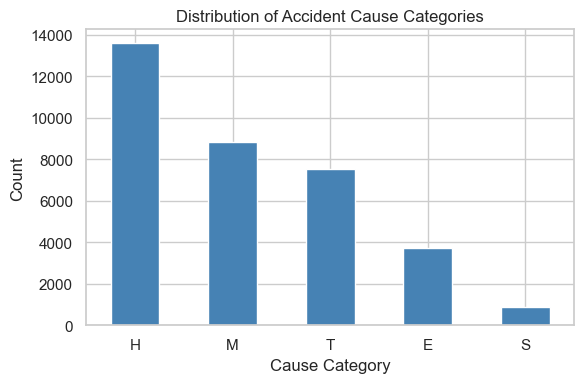

In [34]:
# Visualize cause category distribution
plt.figure(figsize=(6, 4))
df_merged['Cause_Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Accident Cause Categories')
plt.xlabel('Cause Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Exploring Categorical Features

First, let's see what string columns we're working with before deciding
which ones are worth converting to numerical values.

In [35]:
pd.set_option('display.max_columns', None)
df_merged.columns.tolist()

['Reporting Railroad Code',
 'Reporting Railroad Name',
 'Year',
 'Accident Number',
 'PDF Link',
 'Accident Year',
 'Accident Month',
 'Other Railroad Code',
 'Other Railroad Name',
 'Other Accident Number',
 'Other Accident Year',
 'Other Accident Month',
 'Maintenance Railroad Code',
 'Maintenance Railroad Name',
 'Maintenance Accident Number',
 'Maintenance Accident Year',
 'Maintenance Accident Month',
 'Grade Crossing ID',
 'Day',
 'Date',
 'Time',
 'Accident Type Code',
 'Accident Type',
 'Hazmat Cars',
 'Hazmat Cars Damaged',
 'Hazmat Released Cars',
 'Persons Evacuated',
 'Subdivision',
 'Division Code',
 'Division',
 'Station',
 'Milepost',
 'State Code',
 'State Abbreviation',
 'State Name',
 'County Code',
 'County Name',
 'District',
 'Temperature',
 'Visibility Code',
 'Visibility',
 'Weather Condition Code',
 'Weather Condition',
 'Track Type Code',
 'Track Type',
 'Track Name',
 'Track Class',
 'Track Density',
 'Train Direction Code',
 'Train Direction',
 'Equipment Ty

## Identifying Candidate Features for Encoding

Scanning categorical columns to see which ones have a manageable number of
unique values - good candidates for label encoding.

In [36]:
# Viewa few candidates up close
candidates = ['Accident Type', 'Weather Condition', 'Track Type', 'Visibility', 'State Abbreviation']

for col in candidates:
    print(f"\n{col} - unique values: {df_merged[col].nunique()}")
    print(df_merged[col].value_counts().head())


Accident Type - unique values: 13
Accident Type
Derailment                       19113
Other impacts                     5114
Hwy-rail crossing                 3294
Other (describe in narrative)     2155
Side collision                    1689
Name: count, dtype: int64

Weather Condition - unique values: 6
Weather Condition
Clear     23402
Cloudy     7692
Rain       2422
Snow        643
Fog         324
Name: count, dtype: int64

Track Type - unique values: 4
Track Type
Yard        19236
Main        11644
Industry     2893
Siding        787
Name: count, dtype: int64

Visibility - unique values: 4
Visibility
Day     15515
Dark    12227
Dawn     3512
Dusk     3300
Name: count, dtype: int64

State Abbreviation - unique values: 49
State Abbreviation
TX    4220
IL    2816
CA    2130
OH    1334
IN    1308
Name: count, dtype: int64


## Checking Visibility

Quick look at Visibility - unique values and distribution before encoding.

In [37]:
print(f"Visibility - unique values: {df_merged['Visibility'].nunique()}")
print(df_merged['Visibility'].value_counts())

Visibility - unique values: 4
Visibility
Day     15515
Dark    12227
Dawn     3512
Dusk     3300
Name: count, dtype: int64


In [38]:
# Create a dictionary mapping State Abbreviations to US Census Regions
state_to_region = {
    # Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 
    'PA': 'Northeast',
    
    # Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    
    # South
    'DE': 'South', 'DC': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 
    'NC': 'South', 'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 
    'OK': 'South', 'TX': 'South',
    
    # West
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}

# Map the regions to a new column
df_merged['Region'] = df_merged['State Abbreviation'].map(state_to_region)

# Verify the new column
print(df_merged[['State Abbreviation', 'Region']].head())
print("\nRegion Counts:")
print(df_merged['Region'].value_counts(dropna=False))

  State Abbreviation Region
0                 WA   West
1                 KY  South
2                 TN  South
3                 SC  South
4                 FL  South

Region Counts:
Region
South        13818
Midwest      11218
West          5963
Northeast     3563
Name: count, dtype: int64


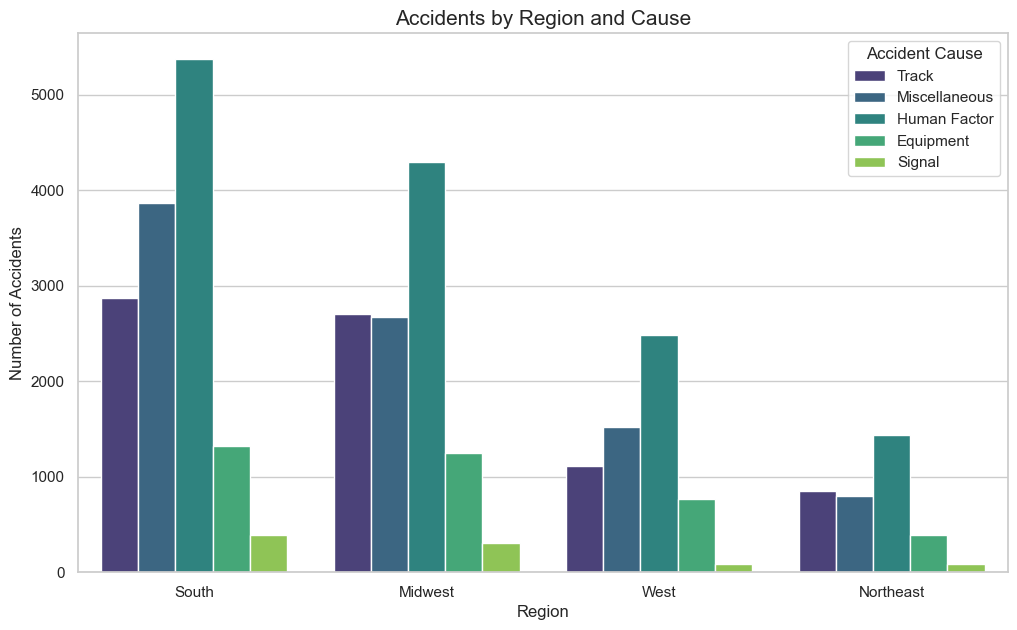

In [39]:
# Ensure Cause_Category exists by extracting the first letter of the Primary Accident Cause Code
# (H=Human Factor, M=Miscellaneous, T=Track, E=Equipment, S=Signal)
if 'Cause_Category' not in df_merged.columns:
    df_merged['Cause_Category'] = df_merged['Primary Accident Cause Code'].str[0]

# Map the single-letter codes to full names for the legend
cause_map = {
    'T': 'Track',
    'E': 'Equipment',
    'H': 'Human Factor',
    'S': 'Signal',
    'M': 'Miscellaneous'
}
df_merged['Cause_Name'] = df_merged['Cause_Category'].map(cause_map)

# Set the figure size
plt.figure(figsize=(12, 7))

# Create a count plot with Region on x-axis and hue (grouping) by Cause
sns.countplot(
    data=df_merged, 
    x='Region', 
    hue='Cause_Name', 
    order=df_merged['Region'].value_counts().index,
    palette='viridis'
)

# Add labels and title
plt.title('Accidents by Region and Cause', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.legend(title='Accident Cause')

# Show the plot
plt.show()

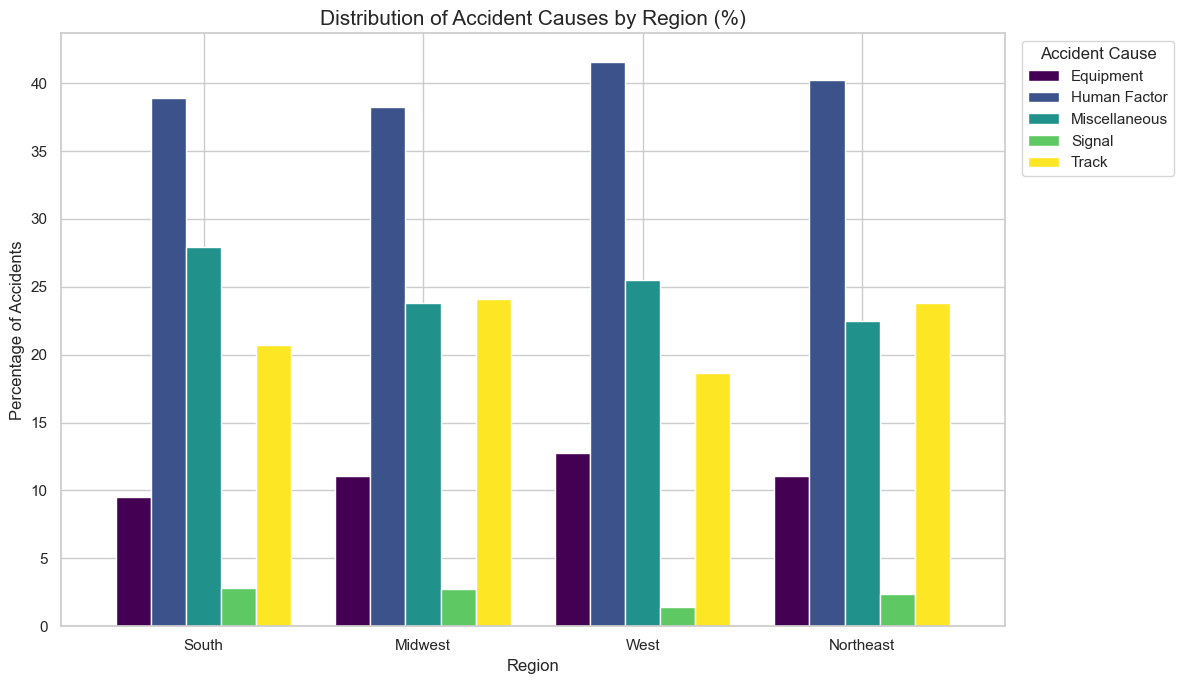

In [40]:
# Calculate the percentage of each cause within each region
# normalize='index' ensures that each row (Region) sums to 1 (100%)
cross_tab = pd.crosstab(df_merged['Region'], df_merged['Cause_Name'], normalize='index') * 100

# Reorder the regions to match the previous chart (by total accident count)
# This keeps the visualization consistent
region_order = df_merged['Region'].value_counts().index
cross_tab = cross_tab.loc[region_order]

# Plot as a grouped bar chart
ax = cross_tab.plot(kind='bar', figsize=(12, 7), width=0.8, colormap='viridis')

# formatting
plt.title('Distribution of Accident Causes by Region (%)', fontsize=15)
plt.ylabel('Percentage of Accidents', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.legend(title='Accident Cause', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Label Encoding Categorical Features

Correlation matrices require numerical inputs, so we convert key categorical
features into numbers using Label Encoding. Each unique category gets assigned
an integer value.

**Note:** `nan` values are getting their own encoded value in each column.
This will need to be addressed later in preprocessing.

In [41]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
cols_to_encode = ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region']

# Create a copy so we don't mess with the original
df_encoded = df_merged.copy()

# Label encode each column
le = LabelEncoder()
for col in cols_to_encode:
    df_encoded[col + '_encoded'] = le.fit_transform(df_merged[col].astype(str))
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Weather Condition: {'Clear': np.int64(0), 'Cloudy': np.int64(1), 'Fog': np.int64(2), 'Rain': np.int64(3), 'Sleet': np.int64(4), 'Snow': np.int64(5), 'nan': np.int64(6)}
Track Type: {'Industry': np.int64(0), 'Main': np.int64(1), 'Siding': np.int64(2), 'Yard': np.int64(3), 'nan': np.int64(4)}
Visibility: {'Dark': np.int64(0), 'Dawn': np.int64(1), 'Day': np.int64(2), 'Dusk': np.int64(3), 'nan': np.int64(4)}
Accident Type: {'Broken train collision': np.int64(0), 'Derailment': np.int64(1), 'Explosion-detonation': np.int64(2), 'Fire/violent rupture': np.int64(3), 'Head on collision': np.int64(4), 'Hwy-rail crossing': np.int64(5), 'Obstruction': np.int64(6), 'Other (describe in narrative)': np.int64(7), 'Other impacts': np.int64(8), 'RR grade crossing': np.int64(9), 'Raking collision': np.int64(10), 'Rear end collision': np.int64(11), 'Side collision': np.int64(12), 'nan': np.int64(13)}
Region: {'Midwest': np.int64(0), 'Northeast': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}


## Correlation Matrix - Relevant Features

We check how candidate features relate to each other to spot redundancy early.
If two features are highly correlated, they're telling the same story and we may
only need one.

**Key findings:**
- **Track Type & Train Speed (-0.38):** Yard tracks run slower than mainlines -
partially redundant.
- **Population & RUCC (-0.37):** Expected overlap - may only need one.
- **Everything else:** Near-zero correlation, meaning each feature brings something
unique to the classification task.

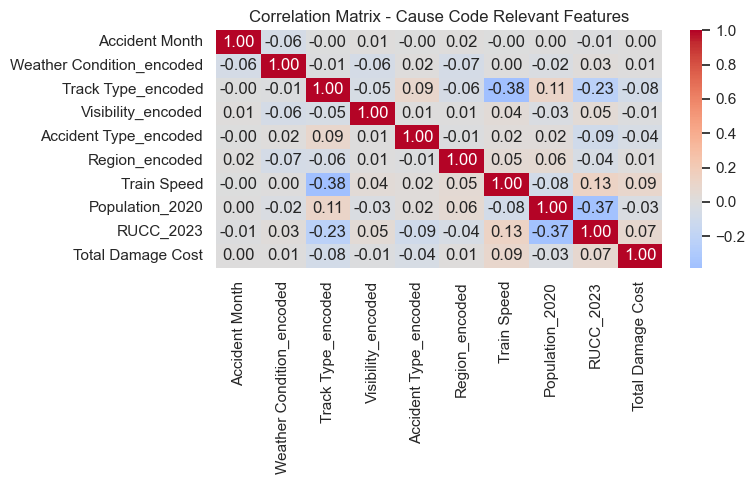

In [42]:
# Clean Total Damage Cost - remove commas and convert to number
df_encoded['Total Damage Cost'] = pd.to_numeric(
    df_encoded['Total Damage Cost'].astype(str).str.replace(',', ''), 
    errors='coerce'
)

# Narrow down to features relevant to cause code prediction
relevant_cols = [
    'Accident Month',
    'Weather Condition_encoded',
    'Track Type_encoded',
    'Visibility_encoded',
    'Accident Type_encoded',
    'Region_encoded',
    'Train Speed',
    'Population_2020',
    'RUCC_2023',
    'Total Damage Cost'
]

# Create focused correlation matrix
corr_focused = df_encoded[relevant_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_focused, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Cause Code Relevant Features')
plt.tight_layout()
plt.show()

## Track Type vs Cause Category

Examining how accident cause categories distribute across different track
types. Each bar group adds to 100%, so we're comparing proportions not
raw counts.

**Key takeaway:** Mainline tracks are dominated by Mechanical failures,
while Yard and Industry tracks show higher Human Factor rates. This makes
operational sense - mainlines run high-speed freight while yards rely
heavily on manual switching movements.

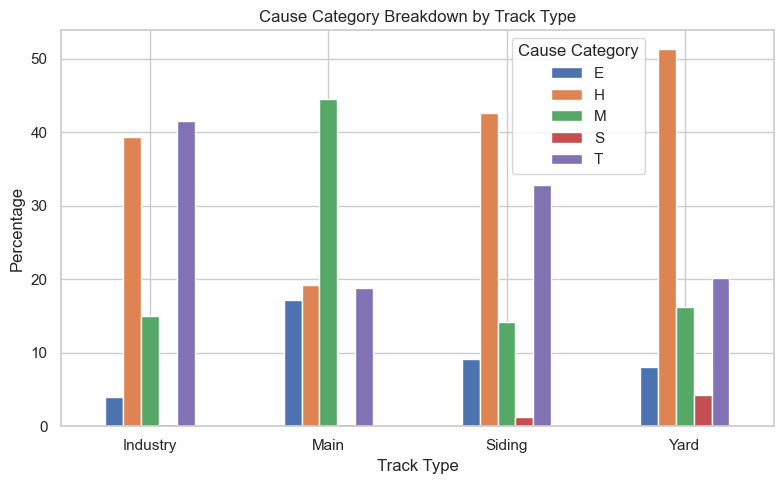

In [43]:
# Track Type vs Cause Category
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df_merged['Track Type'], df_merged['Cause_Category'], normalize='index') * 100
ct.plot(kind='bar', ax=plt.gca())
plt.title('Cause Category Breakdown by Track Type')
plt.xlabel('Track Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Cause Category', loc='upper right', bbox_to_anchor=( .83, 1))
plt.tight_layout()
plt.show()

## RUCC Code vs Cause Category

Looking at how cause categories shift across the metro-to-rural spectrum.
This builds on Phase 1's statistical finding that metro and rural counties
have fundamentally different accident patterns.

**Key takeaway:** Metro counties (RUCC 1-3) are dominated by Human Factor
causes, while rural counties (RUCC 7-9) show a clear increase in Track and
Mechanical failures. The middle RUCC codes (4-6) act as a transition zone
where causes are more evenly distributed.

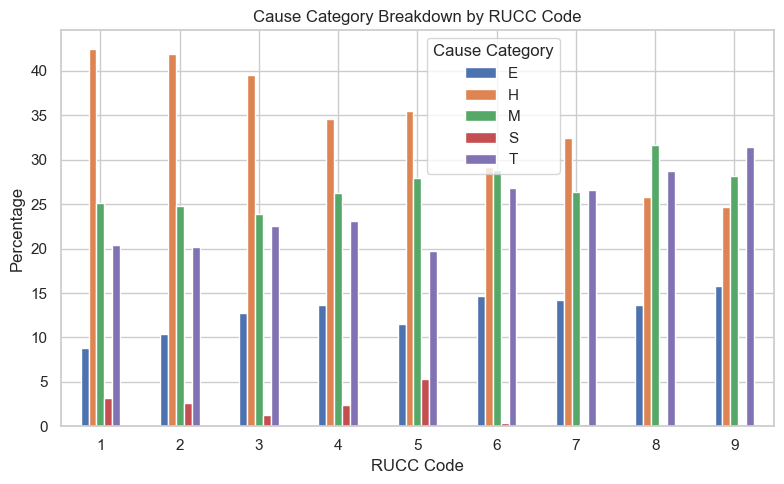

In [44]:
# RUCC vs Cause Category
plt.figure(figsize=(8, 5))
ct_rucc = pd.crosstab(df_merged['RUCC_2023'], df_merged['Cause_Category'], normalize='index') * 100
ct_rucc.plot(kind='bar', ax=plt.gca())
plt.title('Cause Category Breakdown by RUCC Code')
plt.xlabel('RUCC Code')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Cause Category', loc='upper right', bbox_to_anchor=( .71, 1))
plt.tight_layout()
plt.show()

## Accident Month vs Cause Category

Checking for seasonal patterns in cause code distribution. The hypothesis
was that certain causes (Track failures, Environmental) might shift with
seasons due to weather and infrastructure stress.

**Key takeaway:** Cause category proportions remain relatively stable
across all 12 months. Accident Month does not appear to be a strong
predictor of cause codes. This is useful to know - it helps us focus
on the features that actually matter (Track Type, RUCC) going forward.

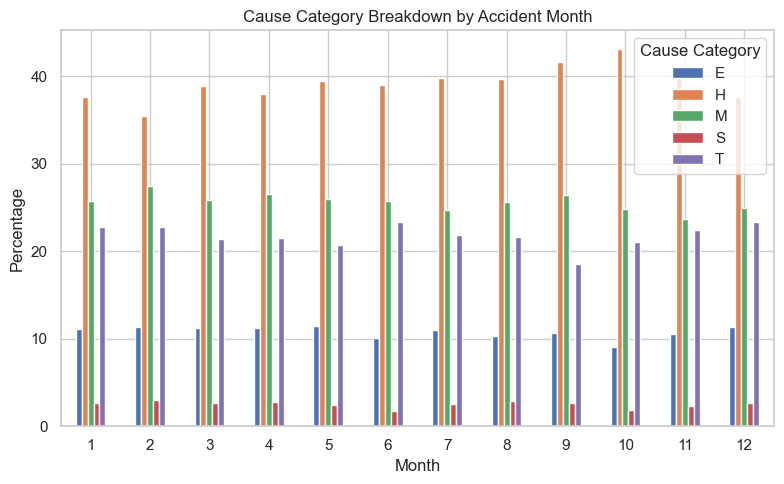

In [45]:
# Accident Month vs Cause Category
plt.figure(figsize=(8, 5))
ct_month = pd.crosstab(df_merged['Accident Month'], df_merged['Cause_Category'], normalize='index') * 100
ct_month.plot(kind='bar', ax=plt.gca())
plt.title('Cause Category Breakdown by Accident Month')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Cause Category')
plt.tight_layout()
plt.show()

## Feature Engineering: Train Composition Metrics

Created three new features to capture train loading characteristics, which may relate to accident risk through factors like slack action, train handling difficulty, and weight distribution:

- **total_cars**: Sum of all cars in the consist (loaded freight, empty freight, loaded passenger, empty passenger, and cabooses)
- **empty_loaded_ratio**: Ratio of empty cars to loaded cars (added 1 to denominator to avoid division by zero)
- **pct_empty**: Percentage of cars in the consist that are empty

These features allow us to explore whether train composition (particularly the proportion of empty cars) differs across accident cause categories.

In [46]:
# Total cars in consist
df_merged['total_cars'] = (df_merged['Loaded Freight Cars'] + df_merged['Empty Freight Cars'] + 
                    df_merged['Loaded Passenger Cars'] + df_merged['Empty Passenger Cars'] + 
                    df_merged['Cabooses'])

# Empty to loaded ratio
df_merged['empty_loaded_ratio'] = (df_merged['Empty Freight Cars'] + df_merged['Empty Passenger Cars']) / \
                             (df_merged['Loaded Freight Cars'] + df_merged['Loaded Passenger Cars'] + 1)

# Or percentage empty
df_merged['pct_empty'] = ((df_merged['Empty Freight Cars'] + df_merged['Empty Passenger Cars']) / 
                   df_merged['total_cars']) * 100


### Distribution of Train Composition Features

Summary statistics for the newly created train composition features:

In [47]:
# Quick look at the distributions - side by side
summary_stats = pd.DataFrame({
    'total_cars': df_merged['total_cars'].describe(),
    'empty_loaded_ratio': df_merged['empty_loaded_ratio'].describe(),
    'pct_empty': df_merged['pct_empty'].describe()
})

print(summary_stats)
print(f"\nZero cars: {(df_merged['total_cars'] == 0).sum()}")
print(f"Infinite values in empty_loaded_ratio: {np.isinf(df_merged['empty_loaded_ratio']).sum()}")

        total_cars  empty_loaded_ratio     pct_empty
count  34562.00000        34562.000000  30430.000000
mean      43.22898            4.882367     39.055297
std       48.34557           19.945770     38.797730
min        0.00000            0.000000      0.000000
25%        2.00000            0.000000      0.000000
50%       24.00000            0.214286     30.000000
75%       76.00000            1.071429     74.358974
max      832.00000          832.000000    100.000000

Zero cars: 4132
Infinite values in empty_loaded_ratio: 0



### Train Compostion Features by Cause Category

In [48]:
# Group by your cause categories
print("\n=== Empty/Loaded Ratio by Cause Category ===")
print(df_merged.groupby('Cause_Category')['empty_loaded_ratio'].agg(['mean', 'median', 'count']))

print("\n=== Percent Empty by Cause Category ===")
print(df_merged.groupby('Cause_Category')['pct_empty'].agg(['mean', 'median', 'count']))


=== Empty/Loaded Ratio by Cause Category ===
                    mean    median  count
Cause_Category                           
E               4.781247  0.285714   3721
H               4.732267  0.433333  13582
M               6.531271  0.011364   8856
S               1.651375  0.470588    867
T               3.637779  0.039268   7534

=== Percent Empty by Cause Category ===
                     mean     median  count
Cause_Category                             
E               36.612395  29.357798   3399
H               46.602091  42.635005  11776
M               36.656126  20.000000   7730
S               42.755492  37.735849    829
T               29.343408  13.513514   6694


## Statistical Significance Test: Percent Empty Across Cause Categories

ANOVA test using scipy.stats to determine if percent empty differs significantly across cause categories.

In [49]:
from scipy.stats import f_oneway

# Get the empty_loaded_ratio for each cause category
groups = [group['pct_empty'].dropna() 
          for name, group in df_merged.groupby('Cause_Category')]

f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Percent empty feature differs significantly across cause categories")
else:
    print("No significant difference")


ANOVA F-statistic: 235.9680
P-value: 0.000000
Percent empty feature differs significantly across cause categories


## Data Cleaning: Gross Tonnage Conversion

Convert Gross Tonnage from string format (with commas) to numeric, then calculate tonnage per car as an additional train characteristic feature.

In [50]:
# # Convert Gross Tonnage to numeric (removes commas)
# df_merged['Gross Tonnage'] = pd.to_numeric(df_merged['Gross Tonnage'].str.replace(',', ''), errors='coerce')

# # Now create tonnage per car
# df_merged['tonnage_per_car'] = df_merged['Gross Tonnage'] / (df_merged['total_cars'] + 1)

# # Check it worked
# print(df_merged['Gross Tonnage'].dtype)
# print(df_merged['Gross Tonnage'].head())


# Convert Gross Tonnage to numeric (handle mixed types by converting to string first)
df_merged['Gross Tonnage'] = pd.to_numeric(
    df_merged['Gross Tonnage'].astype(str).str.replace(',', ''), 
    errors='coerce'
)

# Now create tonnage per car
df_merged['tonnage_per_car'] = df_merged['Gross Tonnage'] / (df_merged['total_cars'] + 1)

# Check it worked
print(df_merged['Gross Tonnage'].dtype)
print(df_merged['Gross Tonnage'].head())

int64
0    1665
1    8691
2       0
3       0
4       0
Name: Gross Tonnage, dtype: int64


## Correlation Analysis: Train Composition Features

Examine correlations between newly created train composition features and existing features to assess redundancy and relationships.

In [51]:
# Create tonnage per car feature
df_merged['tonnage_per_car'] = df_merged['Gross Tonnage'] / (df_merged['total_cars'] + 1)

# Correlation matrix for your new features
features = ['empty_loaded_ratio', 'pct_empty', 'total_cars', 
            'Gross Tonnage', 'tonnage_per_car', 'Train Speed']

corr_matrix = df_merged[features].corr()
print("\n=== Correlation Matrix ===")
print(corr_matrix)


=== Correlation Matrix ===
                    empty_loaded_ratio  pct_empty  total_cars  Gross Tonnage  \
empty_loaded_ratio            1.000000   0.388616    0.264686      -0.021009   
pct_empty                     0.388616   1.000000   -0.044848      -0.250400   
total_cars                    0.264686  -0.044848    1.000000       0.759903   
Gross Tonnage                -0.021009  -0.250400    0.759903       1.000000   
tonnage_per_car              -0.027470  -0.084686    0.051630       0.302444   
Train Speed                   0.038338  -0.204342    0.150901       0.155593   

                    tonnage_per_car  Train Speed  
empty_loaded_ratio        -0.027470     0.038338  
pct_empty                 -0.084686    -0.204342  
total_cars                 0.051630     0.150901  
Gross Tonnage              0.302444     0.155593  
tonnage_per_car            1.000000     0.019575  
Train Speed                0.019575     1.000000  


## Feature Correlation Heatmap: Candidate Features for Classification

Transfer new train composition features to the encoded dataframe and visualize correlations with existing candidate features to assess which features provide unique predictive information for cause code classification.

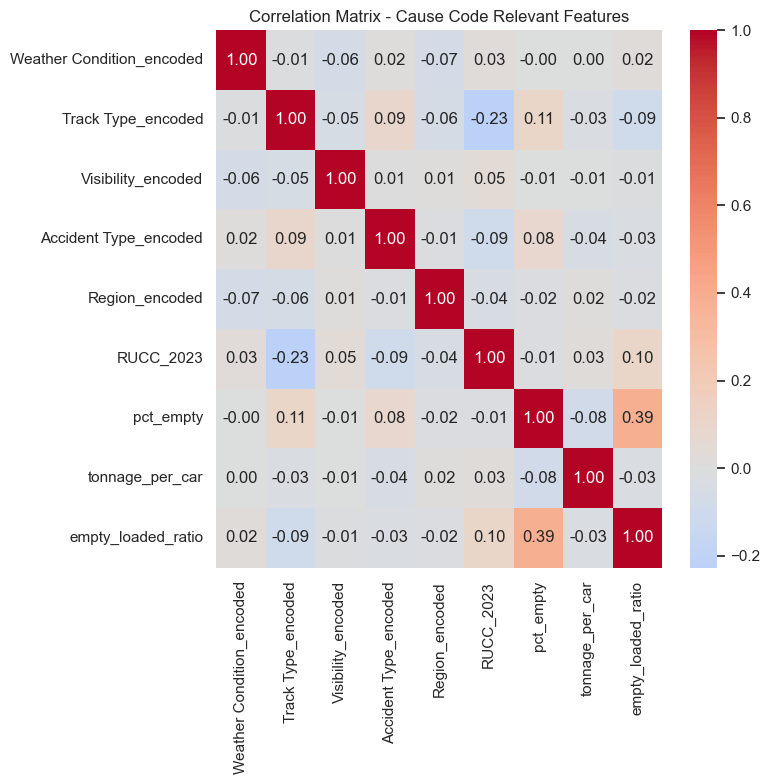

In [59]:
# First, merge the new features into df_encoded
# (assuming df_encoded and df_merged share the same index/can be aligned)

df_encoded['pct_empty'] = df_merged['pct_empty']
df_encoded['tonnage_per_car'] = df_merged['tonnage_per_car']
df_encoded['empty_loaded_ratio'] = df_merged['empty_loaded_ratio']

# Now add them to relevant_cols
relevant_cols = [
    'Weather Condition_encoded',
    'Track Type_encoded',
    'Visibility_encoded',
    'Accident Type_encoded',
    'Region_encoded',
    'RUCC_2023',
    'pct_empty',
    'tonnage_per_car',
    'empty_loaded_ratio'
]

# Create correlation matrix
corr_focused = df_encoded[relevant_cols].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_focused, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Cause Code Relevant Features')
plt.tight_layout()
plt.show()

## Summary: Train Composition Feature Selection

We explored three train composition features to capture loading characteristics that may relate to accident causes through factors like slack action and train handling difficulty:

1. **total_cars**: Total consist length
2. **empty_loaded_ratio**: Ratio of empty to loaded cars
3. **pct_empty**: Percentage of cars that are empty

**Analysis Steps:**

Initial distribution analysis revealed substantial variation in train composition, with a median train consisting of 24 cars and 30% empty. Approximately 12% of accidents involved zero cars, likely yard incidents or single locomotive events.

Grouping by cause category showed meaningful patterns: Track (T) and Mechanical (M) accidents occurred with heavier trains (median 13.5% and 20% empty), while Human Factor (H) accidents occurred with lighter consists (median 42.6% empty). ANOVA testing confirmed these differences were statistically significant (F-statistic: 235.9, p < 0.001).

Correlation analysis between the three candidate features and existing encoded features revealed that **pct_empty** was the strongest candidate because:
- Showed moderate correlation with Track Type (0.11) and RUCC codes (0.10), providing complementary information to existing features
- More interpretable than empty_loaded_ratio
- tonnage_per_car showed essentially no correlation with any features

Based on these findings, **pct_empty** would be our choice as the train composition feature to carry forward for potential inclusion in the classification model. Although, the inclusion of this feature could bias our association rules towards freight-focused accidents.

In [82]:
# Select the original categorical columns for one-hot encoding
cols_to_encode = [
    'Weather Condition', 
    'Track Type', 
    'Visibility', 
    'Accident Type', 
    'Region', 
    'RUCC_2023'
]

# Create df_binary with one-hot encoded variables
# pd.get_dummies will automatically convert these categorical columns to binary 0/1 columns
df_binary = pd.get_dummies(
    df_merged[cols_to_encode], 
    columns=cols_to_encode, 
    dtype=int  # Ensure binary 0/1 output instead of boolean
)

# Verify the new dataframe
print(f"Shape of df_binary: {df_binary.shape}")
print(df_binary.columns.tolist()[:10])  # Show first 10 columns
df_binary.head()

Shape of df_binary: (34562, 40)
['Weather Condition_Clear', 'Weather Condition_Cloudy', 'Weather Condition_Fog', 'Weather Condition_Rain', 'Weather Condition_Sleet', 'Weather Condition_Snow', 'Track Type_Industry', 'Track Type_Main', 'Track Type_Siding', 'Track Type_Yard']


,Weather Condition_Clear,Weather Condition_Cloudy,Weather Condition_Fog,Weather Condition_Rain,Weather Condition_Sleet,Weather Condition_Snow,Track Type_Industry,Track Type_Main,Track Type_Siding,Track Type_Yard,Visibility_Dark,Visibility_Dawn,Visibility_Day,Visibility_Dusk,Accident Type_Broken train collision,Accident Type_Derailment,Accident Type_Explosion-detonation,Accident Type_Fire/violent rupture,Accident Type_Head on collision,Accident Type_Hwy-rail crossing,Accident Type_Obstruction,Accident Type_Other (describe in narrative),Accident Type_Other impacts,Accident Type_RR grade crossing,Accident Type_Raking collision,Accident Type_Rear end collision,Accident Type_Side collision,Region_Midwest,Region_Northeast,Region_South,Region_West,RUCC_2023_1,RUCC_2023_2,RUCC_2023_3,RUCC_2023_4,RUCC_2023_5,RUCC_2023_6,RUCC_2023_7,RUCC_2023_8,RUCC_2023_9
0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0


In [83]:
from sklearn.model_selection import train_test_split

# 1. Drop rows where the Target (Cause_Category) is missing
# We must do this before creating X to ensure X and y have the same number of rows
df_clean = df_merged.dropna(subset=['Cause_Category']).copy()

print(f"Original rows: {len(df_merged)}")
print(f"Rows after dropping missing Cause Codes: {len(df_clean)}")

# 2. Re-create the features (X) using the clean dataframe
# We use the same columns as before
cols_to_encode = [
    'Weather Condition', 
    'Track Type', 
    'Visibility', 
    'Accident Type', 
    'Region', 
    'RUCC_2023'
]

# Create X (features)
X = pd.get_dummies(
    df_clean[cols_to_encode], 
    columns=cols_to_encode, 
    dtype=int
)

# Create y (target)
y = df_clean['Cause_Category']

# 3. Create the 80/20 train-test split
# stratify=y works now because y has no NaNs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify the shapes
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Original rows: 34562
Rows after dropping missing Cause Codes: 34560
Training set shape: (27648, 40)
Testing set shape:  (6912, 40)


Training Random Forest model...

Model Accuracy: 0.5668

Classification Report:
              precision    recall  f1-score   support

           E       0.43      0.22      0.29       744
           H       0.56      0.76      0.64      2716
           M       0.78      0.54      0.64      1771
           S       0.44      0.04      0.07       174
           T       0.46      0.48      0.47      1507

    accuracy                           0.57      6912
   macro avg       0.53      0.41      0.42      6912
weighted avg       0.58      0.57      0.55      6912



C:\Users\David\AppData\Local\Temp\ipykernel_9048\466060290.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


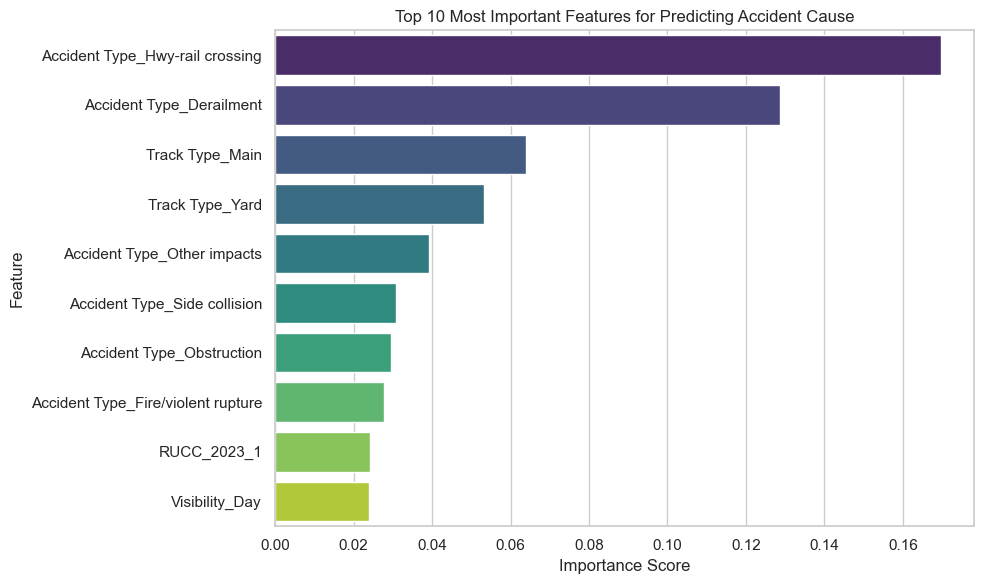

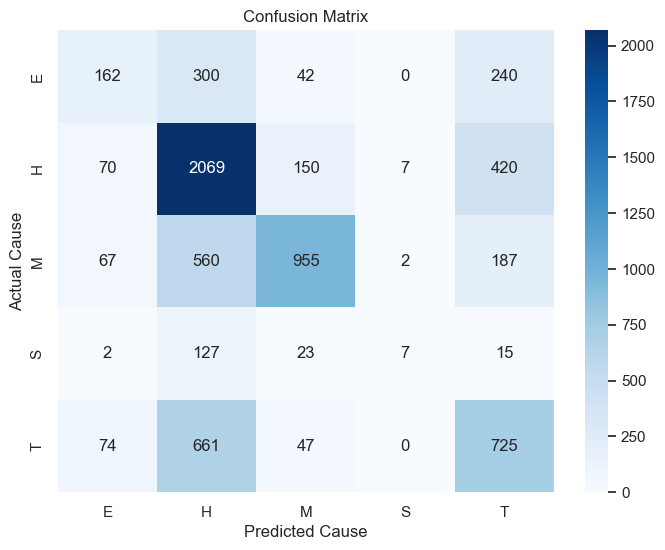

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = rf_model.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Visualize Feature Importance
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Accident Cause')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Optional: Show Confusion Matrix to see where the model gets confused
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Cause')
plt.ylabel('Actual Cause')
plt.show()

# Feature Engineering: Temporal and Operational Features

Building on the initial feature exploration, we now engineer additional categorical features that capture temporal patterns and operational characteristics. This section creates and evaluates candidate features for inclusion in the classification model:

**Features to engineer:**
- **Equipment Type**: Categorize train operations (freight, passenger, yard switching, maintenance)
- **Time of Day**: Bin accident times into four periods (Morning, Afternoon, Evening, Night)
- **Day of Week**: Extract weekday patterns from accident dates
- **Visibility**: Clean and encode existing visibility conditions
- **Signalization**: Clean and encode track signalization status

**Analysis approach:**
After feature creation, we'll encode all features and examine their relationships through correlation analysis. Statistical significance testing (chi-square with Bonferroni correction) will determine which features show meaningful associations with accident cause categories while accounting for multiple comparisons.

**Map Equipment Type**  codes to descriptive labels, and verify **Visibility and Signalization** are clean categorical features ready for encoding.

In [53]:
# Map Equipment Type codes to labels (fix keys to strings)
equipment_type_map = {
    '1': 'Freight Train',
    '2': 'Passenger Train-Pulling',
    '3': 'Commuter Train-Pulling',
    '4': 'Work Train',
    '5': 'Single Car',
    '6': 'Cut of Cars',
    '7': 'Yard/Switching',
    '8': 'Light Loco(s)',
    '9': 'Maint./Inspect. Car',
    'A': 'Spec. MoW Equip.',
    'B': 'Passenger Train-Pushing',
    'C': 'Commuter Train-Pushing',
    'D': 'EMU',
    'E': 'DMU'
}

df_merged['Equipment_Type_Mapped'] = df_merged['Equipment Type Code'].map(equipment_type_map)

print("Equipment Type Mapped counts:")
print(df_merged['Equipment_Type_Mapped'].value_counts())
print(f"\nUnmapped (NaN): {df_merged['Equipment_Type_Mapped'].isna().sum()}")

Equipment Type Mapped counts:
Equipment_Type_Mapped
Freight Train              13699
Yard/Switching              9516
Cut of Cars                 2141
Single Car                  1931
Light Loco(s)               1695
Passenger Train-Pulling     1103
Spec. MoW Equip.             652
EMU                          441
Maint./Inspect. Car          267
Commuter Train-Pulling       236
Commuter Train-Pushing       207
Work Train                   195
Passenger Train-Pushing      191
DMU                           52
Name: count, dtype: int64

Unmapped (NaN): 2236


In [54]:
# Check Visibility output
print("\nVisibility values:")
print(df_merged['Visibility'].value_counts())

# Check Signalization output
print("\nSignalization values:")
print(df_merged['Signalization'].value_counts())


Visibility values:
Visibility
Day     15515
Dark    12227
Dawn     3512
Dusk     3300
Name: count, dtype: int64

Signalization values:
Signalization
Not Signaled    24322
Signaled        10238
Name: count, dtype: int64


Extract **day of week** from the Date field to capture potential weekly patterns in accident causes (e.g., weekday vs. weekend operations, maintenance schedules).

In [55]:
# Extract day of week from Date field
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged['Day_of_Week'] = df_merged['Date'].dt.day_name()

print("Day of Week distribution:")
print(df_merged['Day_of_Week'].value_counts())

Day of Week distribution:
Day_of_Week
Friday       5239
Tuesday      5175
Thursday     5168
Wednesday    5154
Monday       5108
Saturday     4550
Sunday       4168
Name: count, dtype: int64


Extract **hour of day** from Time field and **bin into four daily periods: Morning (4am-10am), Afternoon (10am-4pm), Evening (4pm-10pm), and Night (10pm-4am)** to capture temporal patterns in accident causes.

In [ ]:
# # Extract hour from Time field and bin into 4 periods
# df_merged['Time_parsed'] = pd.to_datetime(df_temp['Time'], format='%I:%M %p', errors='coerce')
# df_merged['Hour'] = df_merged['Time_parsed'].dt.hour

# # Define time of day bins
# def time_of_day_bin(hour):
#     if pd.isna(hour):
#         return None
#     elif 4 <= hour < 10:
#         return 'Morning'
#     elif 10 <= hour < 16:
#         return 'Afternoon'
#     elif 16 <= hour < 22:
#         return 'Evening'
#     else:  # 22-04
#         return 'Night'

# df_merged['Time_of_Day'] = df_merged['Hour'].apply(time_of_day_bin)

# print("Time of Day distribution:")
# print(df_merged['Time_of_Day'].value_counts())
# print(f"\nMissing values: {df_merged['Time_of_Day'].isna().sum()}")

NameError: name 'df_temp' is not defined

### Save all newly engineered features to the merged dataframe for subsequent encoding and analysis.

In [60]:
# Save updated df_merged with all new features
df_merged.to_csv("../data/processed/df_merged.csv.zip", index=False, compression='zip')

print("Saved df_merged with new features:")
print("- Equipment_Type_Mapped")
print("- Day_of_Week")
print("- Time_of_Day")
print("- total_cars")
print("- empty_loaded_ratio")
print("- pct_empty")
print("- tonnage_per_car")
print(f"\nTotal columns: {len(df_merged.columns)}")

Saved df_merged with new features:
- Equipment_Type_Mapped
- Day_of_Week
- Time_of_Day
- total_cars
- empty_loaded_ratio
- pct_empty
- tonnage_per_car

Total columns: 173


Encode newly created categorical features and existing Visibility and Signalization features using LabelEncoder to prepare them for correlation analysis and modeling.

In [61]:
# Encode new categorical features using LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
le_equipment = LabelEncoder()
le_day = LabelEncoder()
le_time = LabelEncoder()
le_visibility = LabelEncoder()
le_signalization = LabelEncoder()
le_region = LabelEncoder()

# Encode features (handling NaN values)
df_encoded['Equipment_Type_encoded'] = le_equipment.fit_transform(df_merged['Equipment_Type_Mapped'].fillna('Unknown'))
df_encoded['Day_of_Week_encoded'] = le_day.fit_transform(df_merged['Day_of_Week'].fillna('Unknown'))
df_encoded['Time_of_Day_encoded'] = le_time.fit_transform(df_merged['Time_of_Day'].fillna('Unknown'))
df_encoded['Visibility_encoded'] = le_visibility.fit_transform(df_merged['Visibility'].fillna('Unknown'))
df_encoded['Signalization_encoded'] = le_signalization.fit_transform(df_merged['Signalization'].fillna('Unknown'))
df_encoded['Region_encoded'] = le_region.fit_transform(df_merged['Region'].fillna('Unknown'))

print("Encoded features:")
print(f"Equipment Type: {dict(zip(le_equipment.classes_, le_equipment.transform(le_equipment.classes_)))}")
print(f"Day of Week: {dict(zip(le_day.classes_, le_day.transform(le_day.classes_)))}")
print(f"Time of Day: {dict(zip(le_time.classes_, le_time.transform(le_time.classes_)))}")
print(f"Visibility: {dict(zip(le_visibility.classes_, le_visibility.transform(le_visibility.classes_)))}")
print(f"Signalization: {dict(zip(le_signalization.classes_, le_signalization.transform(le_signalization.classes_)))}")
print(f"Region: {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}")

Encoded features:
Equipment Type: {'Commuter Train-Pulling': np.int64(0), 'Commuter Train-Pushing': np.int64(1), 'Cut of Cars': np.int64(2), 'DMU': np.int64(3), 'EMU': np.int64(4), 'Freight Train': np.int64(5), 'Light Loco(s)': np.int64(6), 'Maint./Inspect. Car': np.int64(7), 'Passenger Train-Pulling': np.int64(8), 'Passenger Train-Pushing': np.int64(9), 'Single Car': np.int64(10), 'Spec. MoW Equip.': np.int64(11), 'Unknown': np.int64(12), 'Work Train': np.int64(13), 'Yard/Switching': np.int64(14)}
Day of Week: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}
Time of Day: {'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3), 'Unknown': np.int64(4)}
Visibility: {'Dark': np.int64(0), 'Dawn': np.int64(1), 'Day': np.int64(2), 'Dusk': np.int64(3), 'Unknown': np.int64(4)}
Signalization: {'Not Signaled': np.int64(0), 'Signaled': np

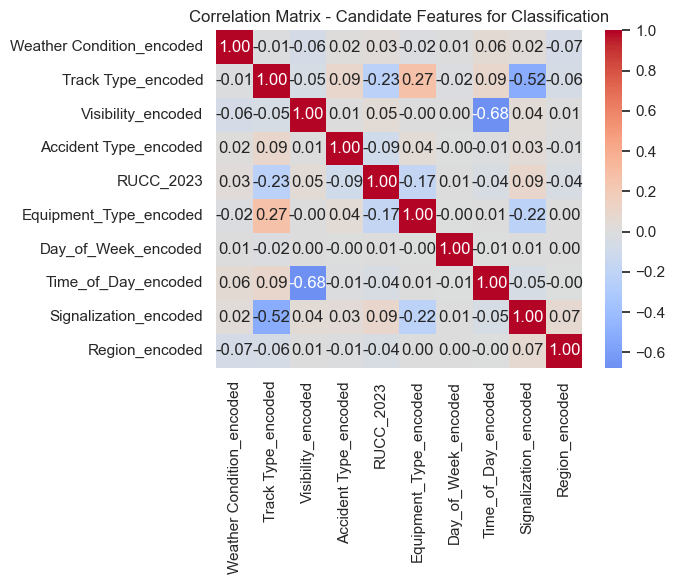

In [62]:
# Create correlation matrix with all candidate features
relevant_cols = [
    'Weather Condition_encoded',
    'Track Type_encoded',
    'Visibility_encoded',
    'Accident Type_encoded',
    'RUCC_2023',
    'Equipment_Type_encoded',
    'Day_of_Week_encoded',
    'Time_of_Day_encoded',
    'Signalization_encoded',
    'Region_encoded'
]

# Create correlation matrix
corr_focused = df_encoded[relevant_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_focused, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Candidate Features for Classification')
plt.tight_layout()
plt.show()

## Correlation Significance Testing with Bonferroni Correction

Calculate p-values for all pairwise correlations in the feature correlation matrix to determine which relationships are statistically significant rather than due to chance. 

**Bonferroni Correction:**
When conducting multiple statistical tests simultaneously, the probability of obtaining at least one false positive (Type I error) increases with each additional test. The Bonferroni correction addresses this "multiple comparisons problem" by dividing the standard significance threshold (α = 0.05) by the number of tests being performed. This creates a more conservative threshold that maintains the overall family-wise error rate at 5%.

For our analysis with 36 pairwise feature comparisons, the Bonferroni-corrected threshold becomes 0.05/36 = 0.00139. This stricter criterion ensures that correlations we identify as significant are unlikely to be false discoveries, even when testing many relationships simultaneously.

**Purpose:**
We're identifying which feature pairs show genuine statistical relationships that survive the conservative Bonferroni threshold. This helps us understand which features may be redundant (highly correlated with each other) versus which provide independent predictive information. Features with strong, significant correlations are candidates for exclusion to avoid multicollinearity in our classification models.

**Interpreting results:**
P-values below the Bonferroni threshold (0.00139) indicate statistically significant correlations that are highly unlikely to be due to chance. Feature pairs with both high correlation coefficients (e.g., |r| > 0.5) and significant p-values represent strong redundancy - these features measure similar underlying information and including both in a model would be problematic. Conversely, features showing no significant correlations with others provide independent predictive information.

In [63]:
from scipy.stats import pearsonr

# Calculate p-values for each pairwise correlation
n_features = len(relevant_cols)
p_values = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i != j:
            _, p_val = pearsonr(df_encoded[relevant_cols[i]].dropna(), 
                               df_encoded[relevant_cols[j]].dropna())
            p_values[i, j] = p_val
        else:
            p_values[i, j] = 0  # diagonal

# Create DataFrame for p-values
p_values_df = pd.DataFrame(p_values, 
                           index=relevant_cols, 
                           columns=relevant_cols)

# Apply Bonferroni correction
n_tests = (n_features * (n_features - 1)) / 2  # number of unique pairs
bonferroni_alpha = 0.05 / n_tests

print(f"Number of correlation tests: {n_tests}")
print(f"Bonferroni corrected alpha: {bonferroni_alpha:.6f}")
print("\nP-values for correlations:")
print(p_values_df.round(6))

Number of correlation tests: 45.0
Bonferroni corrected alpha: 0.001111

P-values for correlations:
                           Weather Condition_encoded  Track Type_encoded  \
Weather Condition_encoded                   0.000000            0.040132   
Track Type_encoded                          0.040132            0.000000   
Visibility_encoded                          0.000000            0.000000   
Accident Type_encoded                       0.003222            0.000000   
RUCC_2023                                   0.000001            0.000000   
Equipment_Type_encoded                      0.000119            0.000000   
Day_of_Week_encoded                         0.060937            0.000190   
Time_of_Day_encoded                         0.000000            0.000000   
Signalization_encoded                       0.000006            0.000000   
Region_encoded                              0.000000            0.000000   

                           Visibility_encoded  Accident Type_enc

Display pairwise correlations alongside their statistical significance after Bonferroni correction to identify which feature relationships are genuine versus potentially due to chance.

The code creates a boolean mask (True/False table) indicating which p-values meet the Bonferroni threshold, then systematically examines each unique feature pair. By iterating through only the upper triangle of the correlation matrix, we avoid redundant comparisons (e.g., examining both "Feature A vs Feature B" and "Feature B vs Feature A" when they represent the same relationship).

For each feature pair, we extract three key pieces of information: the correlation coefficient (strength and direction of relationship), the p-value (probability the correlation occurred by chance), and a significance determination based on whether the p-value passes the Bonferroni-corrected threshold.

**Interpreting significance:**
A "YES" designation indicates the correlation is statistically significant even after the strict Bonferroni correction - meaning the relationship between those features is real and not due to random chance. Feature pairs marked "YES" with high correlation values (e.g., |r| > 0.5) represent potential redundancy concerns, as they measure related information. A "NO" designation means the correlation, while possibly present, is not strong enough to be considered statistically reliable after accounting for multiple testing.

This side-by-side presentation allows us to distinguish between correlations that are both strong and statistically significant (potential redundancy concerns) versus correlations that may appear notable but don't achieve statistical significance after accounting for multiple comparisons.

In [64]:
# Create significance mask
significant_bonferroni = p_values_df < bonferroni_alpha

# Display comparison
print("Correlations significant after Bonferroni correction:")
print("(Only showing upper triangle to avoid duplicates)\n")

for i in range(len(relevant_cols)):
    for j in range(i+1, len(relevant_cols)):
        corr_val = corr_focused.iloc[i, j]
        p_val = p_values_df.iloc[i, j]
        sig = "YES" if p_val < bonferroni_alpha else "NO"
        
        print(f"{relevant_cols[i]} vs {relevant_cols[j]}")
        print(f"  Correlation: {corr_val:.3f}, P-value: {p_val:.6f}, Significant: {sig}")
        print()

Correlations significant after Bonferroni correction:
(Only showing upper triangle to avoid duplicates)

Weather Condition_encoded vs Track Type_encoded
  Correlation: -0.011, P-value: 0.040132, Significant: NO

Weather Condition_encoded vs Visibility_encoded
  Correlation: -0.062, P-value: 0.000000, Significant: YES

Weather Condition_encoded vs Accident Type_encoded
  Correlation: 0.016, P-value: 0.003222, Significant: NO

Weather Condition_encoded vs RUCC_2023
  Correlation: 0.027, P-value: 0.000001, Significant: YES

Weather Condition_encoded vs Equipment_Type_encoded
  Correlation: -0.021, P-value: 0.000119, Significant: YES

Weather Condition_encoded vs Day_of_Week_encoded
  Correlation: 0.010, P-value: 0.060937, Significant: NO

Weather Condition_encoded vs Time_of_Day_encoded
  Correlation: 0.057, P-value: 0.000000, Significant: YES

Weather Condition_encoded vs Signalization_encoded
  Correlation: 0.024, P-value: 0.000006, Significant: YES

Weather Condition_encoded vs Region_

## Summary: Pearson Correlation and Bonferroni Correction Findings

Analysis of pairwise feature correlations with Bonferroni-corrected significance testing (α = 0.00139 for 36 tests) revealed several key patterns in feature relationships:

**Strong redundancy identified:**
- Visibility and Time_of_Day show high negative correlation (-0.676, p < 0.001), indicating these features measure essentially the same underlying information (lighting conditions vary predictably with time). Only one should be retained to avoid multicollinearity.
- Track Type and Signalization demonstrate moderate negative correlation (-0.518, p < 0.001), reflecting that yard tracks are typically unsignalized while mainline tracks are signalized. These features contain overlapping information.

**Moderate correlations:**
- Track Type shows significant correlations with Equipment Type (0.273), RUCC codes (-0.228), and multiple other features, suggesting it captures operational context that intersects with several dimensions.
- Equipment Type correlates moderately with RUCC (-0.173) and Signalization (-0.224), reflecting differences between urban and rural operations.

**Independent features:**
- Day of Week shows no statistically significant correlations with any other features after Bonferroni correction, providing unique temporal information.
- Weather Condition and Accident Type show only weak correlations with other features, suggesting they contribute independent predictive information.

These findings indicate that from our nine candidate features, we should select one feature from each highly correlated pair (Visibility/Time_of_Day and Track Type/Signalization) while retaining the independent features. Final feature selection will also consider each feature's individual predictive power for accident cause categories through chi-square testing.

## Chi-Square Independence Tests with Bonferroni Correction

Test whether each candidate feature is statistically associated with accident Cause_Category using chi-square tests of independence. 

Chi-square tests evaluate whether the distribution of cause categories differs significantly across the levels of each feature. A significant result indicates that knowing a feature's value provides information about the likely accident cause, making it a potentially useful predictor for classification.

Since we're conducting multiple tests (one for each of the 9 features), we apply Bonferroni correction by dividing the standard significance level (0.05) by the number of tests. This adjusted threshold controls for the increased risk of false positives when performing multiple hypothesis tests.

For each feature, we calculate the chi-square statistic, p-value, and degrees of freedom, then compare both the raw p-value (α = 0.05) and Bonferroni-corrected p-value to determine significance. Features that remain significant after Bonferroni correction demonstrate robust associations with accident causes and are strong candidates for inclusion in classification models.

**Interpreting results:**
The chi-square statistic measures the magnitude of association between each feature and accident causes - higher values indicate stronger relationships. P-values indicate the probability of observing such an association by random chance. Features with p-values below the Bonferroni threshold demonstrate statistically significant associations that are unlikely to be false discoveries. The "Sig_Bonferroni" column identifies features that pass this conservative threshold and represent the most reliable predictors. Combined with the correlation analysis, these results guide final feature selection by balancing predictive power (chi-square s

In [65]:
from scipy.stats import chi2_contingency

# Chi-square test for each feature vs Cause_Category
chi_square_results = []

for feature in relevant_cols:
    contingency = pd.crosstab(df_encoded[feature], df_encoded['Cause_Category'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    
    chi_square_results.append({
        'Feature': feature,
        'Chi2': chi2,
        'P-value': p_val,
        'DOF': dof
    })

chi_results_df = pd.DataFrame(chi_square_results)

n_tests = len(relevant_cols)
bonferroni_alpha_chi = 0.05 / n_tests

chi_results_df['Sig_raw'] = chi_results_df['P-value'] < 0.05
chi_results_df['Sig_Bonferroni'] = chi_results_df['P-value'] < bonferroni_alpha_chi

print(f"Bonferroni corrected alpha: {bonferroni_alpha_chi:.6f}\n")
print(chi_results_df.to_string(index=False))

Bonferroni corrected alpha: 0.005000

                  Feature         Chi2       P-value  DOF  Sig_raw  Sig_Bonferroni
Weather Condition_encoded   221.901534  5.686543e-34   24     True            True
       Track Type_encoded  6191.808652  0.000000e+00   16     True            True
       Visibility_encoded   262.358092  1.499365e-46   16     True            True
    Accident Type_encoded 21483.325831  0.000000e+00   52     True            True
                RUCC_2023   740.735930 3.820692e-135   32     True            True
   Equipment_Type_encoded  6801.284558  0.000000e+00   56     True            True
      Day_of_Week_encoded    87.514228  3.702854e-09   24     True            True
      Time_of_Day_encoded   235.988151  3.825897e-41   16     True            True
    Signalization_encoded  4533.414499  0.000000e+00    8     True            True
           Region_encoded   217.915118  6.421600e-40   12     True            True


## Summary: Chi-Square Independence Test Findings

Chi-square tests with Bonferroni correction (α = 0.00556 for 9 tests) evaluated whether each feature for consideration shows statistically significant associations with accident Cause_Category.

**Key findings:**
All nine candidate features demonstrated statistically significant associations with accident causes, with p-values well below the Bonferroni-corrected threshold. This indicates that each feature provides genuine predictive information about accident cause categories.

**Features with strongest associations (highest chi-square statistics):**
- Accident Type: Extremely strong association with cause categories
- Equipment Type: Very strong predictor of accident causes  
- Track Type and Signalization: Both show very strong associations
- RUCC codes: Strong association confirming rural/urban patterns differ by cause

**Features with moderate associations:**
- Time of Day and Visibility: Both significant predictors
- Weather Condition: Significant but more modest association
- Day of Week: Weakest association among significant features, but still passes Bonferroni correction

**Implications for feature selection:**
While all features are statistically significant predictors, the correlation analysis revealed redundancy between certain pairs (Visibility/Time_of_Day and Track Type/Signalization). Since both members of these pairs are significant, the choice of which to retain should be based on interpretability, data quality, and team discussion. Features showing both strong predictive power and independence from other features (Equipment Type, RUCC, Accident Type, Weather Condition, Day of Week) are clear candidates for inclusion in classification models.

# Phase 2: Cause Code EDA - Summary

## What We Did

Starting from the cleaned merged dataframe produced in Phase 1, we explored
features to understand which ones show meaningful differences across
the five accident cause categories (H, M, T, E, S).

1. **Correlation Matrix** - Checked relationships between numerical features
to identify redundancy. Found Track Type/Train Speed and Population/RUCC
are partially redundant pairs.

2. **Track Type vs Cause Category** - Mainline tracks are dominated by
Mechanical failures, while Yards and Industry tracks show higher Human
Factor rates. Strong signal for classification.

3. **RUCC Code vs Cause Category** - Metro counties (1-3) are dominated
by Human Factor causes, while rural counties (7-9) show increasing Track
and Mechanical failures. Visually confirms Phase 1's statistical findings.

4. **Accident Month vs Cause Category** - Cause proportions remain stable
across all 12 months. Month does not appear to be a strong predictor -
useful to know what to deprioritize.

5. **Train Composition (pct_empty)** - Engineered feature measuring percentage
of empty cars in consist. Track and Mechanical accidents occur with heavier trains
(lower pct_empty), while Human Factor accidents occur with lighter consists
(higher pct_empty). ANOVA confirmed statistical significance (p < 0.001).
Shows moderate correlation with Track Type and RUCC, providing complementary information.

## Key Takeaways

- **Track Type**, **RUCC Code**, and **pct_empty** are the strongest candidates for
cause code classification so far
- **Accident Month** can likely be deprioritized
- Due to redundancy, we likely only need one of Population/RUCC and one
of Track Type/Train Speed going forward

## Possible Next Steps

- Feature engineering: Create US Census region from state codes to capture
broader geographic patterns beyond RUCC
- Begin feature selection - narrow down to the most useful features
before moving into classification
- Coordinate with the team on shared preprocessing decisions
(e.g., handling the nan values in encoded columns)
- Consider a simple baseline classifier (e.g., Logistic Regression)
to establish a benchmark before trying more complex models